In [1]:
from utils import get_gsm8k_df
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3
import numpy as np
df = get_gsm8k_df("ReAct")

qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx


# Misclassified

In [2]:
df_misc = get_gsm8k_df("ReAct", include_misclassified=True)
df_misc = df_misc[df_misc["Error Type"] == "Misclassified"]
df_misc.groupby(["Model", "Error Class"]).agg({
    "question": "count",
}).reset_index().sort_values(by="question", ascending=False).head(50)

qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx


,Model,Error Class,question
2,qwen3:0.6b,Misclassified,5
3,qwen3:1.7b,Misclassified,2
0,llama3.2:1b,Misclassified,1
1,qwen2.5:0.5b,Misclassified,1


In [3]:
overall_misc_rate = len(df_misc) / len(df)
print(f"Total misclassified examples: {len(df_misc)}")
print(f"Total examples: {len(df)}")
print(f"Overall misclassification rate: {overall_misc_rate:.2%}")

Total misclassified examples: 9
Total examples: 1200
Overall misclassification rate: 0.75%


# Accuracy

## Sorted

In [4]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="is_correct", ascending=False)
df_acc

,Model,is_correct
3,qwen3:1.7b,0.853333
2,qwen3:0.6b,0.646667
0,llama3.2:1b,0.240000
1,qwen2.5:0.5b,0.156667


## Alphabetical

In [5]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="Model", ascending=True)
df_acc

,Model,is_correct
0,llama3.2:1b,0.240000
1,qwen2.5:0.5b,0.156667
2,qwen3:0.6b,0.646667
3,qwen3:1.7b,0.853333


# Error Analysis

## Overview

In [7]:
df_err = df.groupby(["Model", "Error Type", "Error Class"]).agg({
    "question": "count",
}).pivot_table(
    index=["Model"],
    columns=["Error Type", "Error Class"],
    values="question",
    fill_value=0
).reset_index()

df_err.head(50)

Error Type          Model   Execution Error                                    \
Error Class               Calculation Error Loop Overthinking Wrong Reasoning   
0             llama3.2:1b               0.0  0.0          0.0           210.0   
1            qwen2.5:0.5b               0.0  0.0          0.0           220.0   
2              qwen3:0.6b               1.0  6.0         12.0            87.0   
3              qwen3:1.7b               0.0  0.0         15.0            29.0   

Error Type  Tool Error  
Error Class Tool Error  
0                 18.0  
1                 33.0  
2                  0.0  
3                  0.0

In [9]:
print(df_err.to_latex(index=False, caption='Anzahl der Fehlerarten und -klassen für GSM8K nach Modell', label='tab:error_types_gsm8k'))

\begin{table}
\caption{Anzahl der Fehlerarten und -klassen für GSM8K nach Modell}
\label{tab:error_types_gsm8k}
\begin{tabular}{lrrrrr}
\toprule
Model & \multicolumn{4}{r}{Execution Error} & Tool Error \\
 & Calculation Error & Loop & Overthinking & Wrong Reasoning & Tool Error \\
\midrule
llama3.2:1b & 0.000000 & 0.000000 & 0.000000 & 210.000000 & 18.000000 \\
qwen2.5:0.5b & 0.000000 & 0.000000 & 0.000000 & 220.000000 & 33.000000 \\
qwen3:0.6b & 1.000000 & 6.000000 & 12.000000 & 87.000000 & 0.000000 \\
qwen3:1.7b & 0.000000 & 0.000000 & 15.000000 & 29.000000 & 0.000000 \\
\bottomrule
\end{tabular}
\end{table}



## Plots

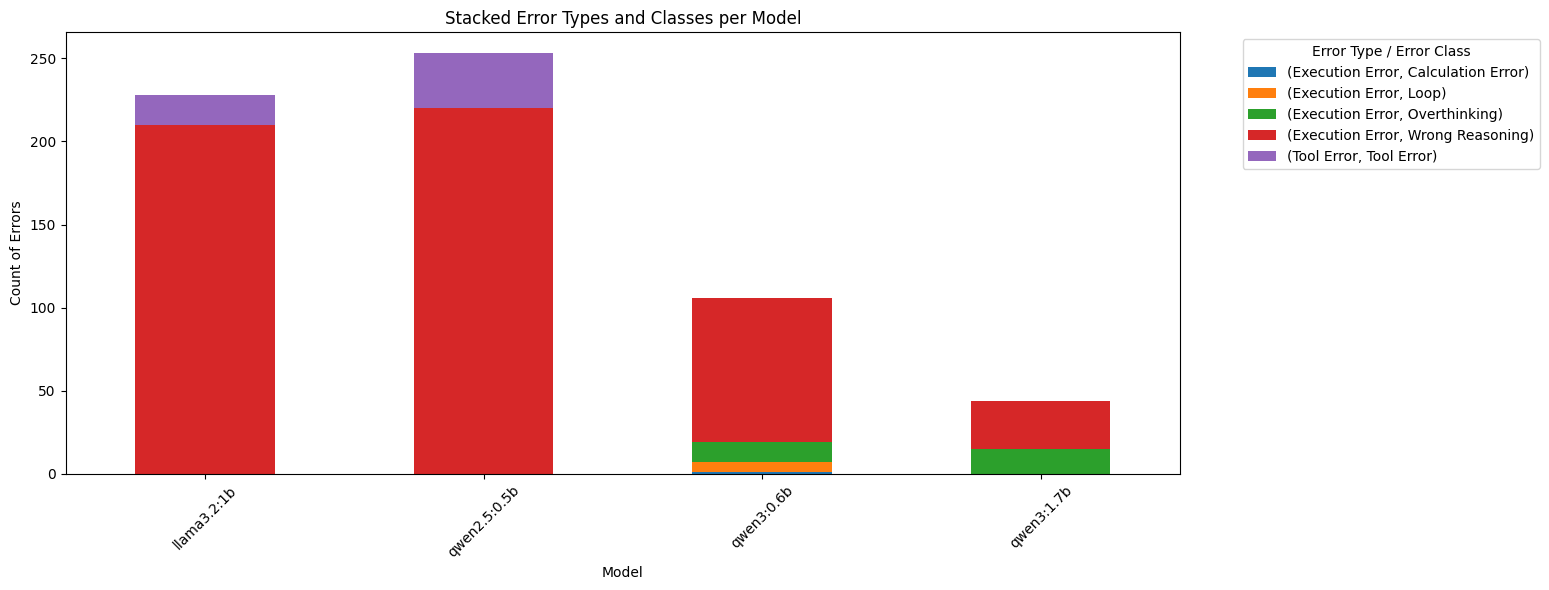

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Set index to "Model" to prepare for plotting
df_plot = df_err.set_index("Model")

# Plot as stacked bar chart
df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Count of Errors")
plt.title("Stacked Error Types and Classes per Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Error Type / Error Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Question Type

In [8]:
# Different question types
def classify_question_type(question):
    if "how many" in question.lower():
        return "How Many"
    elif "how much" in question.lower():
        return "How Much"
    elif "what" in question.lower():
        return "What"
    elif "calculate" in question.lower():
        return "Calculate"
    elif "how" in question.lower():
        return "How"
    return np.nan

df_qt = df.copy()
df_qt['Question_Type'] = df['question'].apply(classify_question_type)
print("NAN Question Types:", df_qt['Question_Type'].isna().sum())

# show ten questions with NaN question types
for question in df_qt[df_qt['Question_Type'].isna()]['question']:
    print(question)

# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df_qt.iterrows():
        if row['question'] not in seen_ids:
            seen_ids.add(row['question'])
            if row['Question_Type'] not in question_type_mapping:
                question_type_mapping[row['Question_Type']] = 0
            question_type_mapping[row['Question_Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

NAN Question Types: 0


,Question Type,Count
1,How Many,166
0,How Much,76
3,What,29
2,How,15
4,Calculate,14


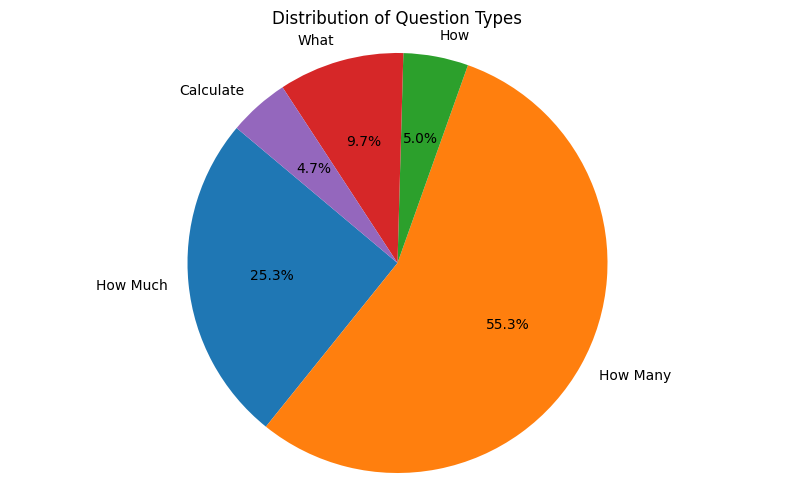

In [9]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [10]:
qtypes_df = df_qt.groupby(["Model", "Question_Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Question_Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100
qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

Model,ollama/llama3.2_1b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b
Question_Type,,,,
Calculate,21.428571,7.142857,71.428571,92.857143
How,13.333333,6.666667,73.333333,86.666667
How Many,27.108434,16.265060,65.060241,87.951807
How Much,25.000000,22.368421,63.157895,81.578947
What,10.344828,3.448276,58.620690,75.862069


In [11]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))
                print(f"Comparing {p1} (n={n1}) with {p2} (n={n2}) for model {model}")

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df.head(10)

Comparing 0.2236842105263158 (n=76) with 0.034482758620689655 (n=29) for model ollama/qwen2.5_0.5b


,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/qwen2.5_0.5b,How Much,22.368421,What,3.448276,0.021212,True


Interpretation

- **Qwen2.5 0.5b**: performs significantly worse on *what* than on *how much*

# Tool Usage

In [11]:
df_tool = df.copy()
df_tool['Tool_Counter'] = df_tool['reasoning'].apply(lambda x: x.count('[TOOL]:'))
df_tool['Tool_Used'] = df_tool['Tool_Counter'] > 0

df_tool.groupby(['Model']).agg({
    'Tool_Counter': 'sum',
    'Tool_Used': 'mean',
    'is_correct': 'mean'
})

,Tool_Counter,Tool_Used,is_correct
Model,,,
llama3.2:1b,307,0.990000,0.240000
qwen2.5:0.5b,304,0.940000,0.156667
qwen3:0.6b,11,0.033333,0.646667
qwen3:1.7b,228,0.710000,0.853333


In [14]:
# Check if tool was used if it was correct
df_tool_analysis = df_tool.groupby(['Model', "Tool_Used"]).agg({
    'is_correct': ['mean', "count"]
})
df_tool_analysis

is_correct      
                                    mean count
Model               Tool_Used                 
ollama/llama3.2_1b  False       0.000000     3
                    True        0.242424   297
ollama/qwen2.5_0.5b False       0.333333    18
                    True        0.145390   282
ollama/qwen3_0.6b   False       0.658621   290
                    True        0.300000    10
ollama/qwen3_1.7b   False       0.781609    87
                    True        0.882629   213

In [14]:
df_tool.groupby(['Model', "Tool_Used"]).agg({
    'is_correct': 'count'
}).pivot_table(
    index='Model',
    columns='Tool_Used',
    values='is_correct',
    fill_value=0
).reset_index()

Tool_Used,Model,False,True
0,llama3.2:1b,3.0,297.0
1,qwen2.5:0.5b,18.0,282.0
2,qwen3:0.6b,290.0,10.0
3,qwen3:1.7b,87.0,213.0


In [13]:
# Check if tool was used if it was correct
print(df_tool.groupby(['Model', "Tool_Used"]).agg({
    'is_correct': 'count'
}).pivot_table(
    index='Model',
    columns='Tool_Used',
    values='is_correct',
    fill_value=0
).reset_index().to_latex(index=False, caption='Anzahl der korrekten Antworten bei Nutzung des Tools für GSM8K nach Modell', label='tab:correct_tool_usage_svamp'))

\begin{table}
\caption{Anzahl der korrekten Antworten bei Nutzung des Tools für GSM8K nach Modell}
\label{tab:correct_tool_usage_svamp}
\begin{tabular}{lrr}
\toprule
Model & False & True \\
\midrule
llama3.2:1b & 3.000000 & 297.000000 \\
qwen2.5:0.5b & 18.000000 & 282.000000 \\
qwen3:0.6b & 290.000000 & 10.000000 \\
qwen3:1.7b & 87.000000 & 213.000000 \\
\bottomrule
\end{tabular}
\end{table}



In [23]:
df_tool_analysis.to_records()

data = {}
for entry in df_tool_analysis.to_records():
    model, tool_used, is_correct_mean, count = entry
    if model not in data:
        data[model] = {}
    data[model][tool_used] = {
        'is_correct_mean': is_correct_mean,
        'count': count
    }

significant_results_tool = {}
for model, tool_data in data.items():
    significant_results_tool[model] = []
    if True in tool_data and False in tool_data:
        p1 = tool_data[True]['is_correct_mean']
        n1 = tool_data[True]['count']
        p2 = tool_data[False]['is_correct_mean']
        n2 = tool_data[False]['count']
        
        result = compare_accuracies_v3(p1, n1, p2, n2)
        if result.is_significant:
            significant_results_tool[model].append((p1, n1, p2, n2, result.p_value, result.is_significant))
            print(f"Comparing Tool Used vs Not Used for model {model}")
significant_results_tool_df = pd.DataFrame([
    {
        'Model': model,
        'Score_Used': item[0],
        'Score_Not_Used': item[2],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results_tool.items()
    for item in items
])
significant_results_tool_df.head(10)

Comparing Tool Used vs Not Used for model ollama/qwen2.5_0.5b
Comparing Tool Used vs Not Used for model ollama/qwen3_0.6b
Comparing Tool Used vs Not Used for model ollama/qwen3_1.7b


,Model,Score_Used,Score_Not_Used,p_value,is_significant
0,ollama/qwen2.5_0.5b,0.145390,0.333333,0.045047,True
1,ollama/qwen3_0.6b,0.300000,0.658621,0.037152,True
2,ollama/qwen3_1.7b,0.882629,0.781609,0.041193,True


Interpretation

similar to SVAMP intepretation:

* **Llama** and **Qwen 2.5 0.5B** almost always use Tools but perform significantly worse than the Qwen3 models
* **Qwen 2.5 0.B** performs significantly better without tools whereas **Llama** performs (insignificantly) worse with tools (count is too ittle for no-tool-usage)
* **Qwen3 0.6B** uses almost no tools and performs with tools significantly worse
* **Qwen3 1.7B** uses more than twice as often tools and achieves significantly better performance with tool usage.